# Setup

In [1]:
import re
import ipaddress
import json
import warnings
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10


# Load

In [2]:
data_dir = Path('../temp/uploads') if Path('../temp/uploads').exists() else Path('temp/uploads')
output_dir = Path('../data/processed') if Path('../data/processed').exists() else Path('data/processed')
output_dir.mkdir(parents=True, exist_ok=True)

df_id = pd.read_csv(data_dir / 'track2_identity_asset_master.csv')
with open(data_dir / 'track2_iam_audit_trail.json', 'r', encoding='utf-8') as f:
    df_iam = pd.DataFrame(json.load(f))
df_fw = pd.read_csv(data_dir / 'track2_firewall_logs.csv')
df_ep = pd.read_excel(data_dir / 'track2_endpoint_alerts.xlsx')

print('Identity Master:', df_id.shape)
print(df_id.dtypes)
print('\nIAM Audit Trail:', df_iam.shape)
print(df_iam.dtypes)
print('\nFirewall Logs:', df_fw.shape)
print(df_fw.dtypes)
print('\nEndpoint Alerts:', df_ep.shape)
print(df_ep.dtypes)


Identity Master: (3090, 12)
user_id             object
username            object
full_name           object
department          object
role                object
location            object
hostname            object
device_id           object
status              object
hire_date           object
termination_date    object
manager_username    object
dtype: object

IAM Audit Trail: (20500, 15)
event_id          object
timestamp         object
user_id           object
username          object
department        object
event_type        object
auth_method       object
source_ip         object
hostname          object
device_id         object
session_id        object
mfa_passed        object
failure_reason    object
risk_score        object
geo_location      object
dtype: object

Firewall Logs: (30600, 15)
log_id             object
timestamp          object
hostname           object
src_ip             object
dst_ip             object
src_port          float64
dst_port          float64
proto

# Raw profile

In [3]:
dfs = {
    'identity': (df_id, 'user_id'),
    'iam': (df_iam, 'event_id'),
    'firewall': (df_fw, 'log_id'),
    'endpoint': (df_ep, 'alert_id')
}

profile_rows = []
for name, (df, key) in dfs.items():
    profile_rows.append({
        'dataset': name,
        'rows': len(df),
        'cols': df.shape[1],
        'total_nulls': df.isna().sum().sum(),
        'duplicate_rows': df.duplicated().sum(),
        'duplicate_keys': df.duplicated(subset=[key]).sum() if key in df.columns else np.nan
    })
print(pd.DataFrame(profile_rows).to_string(index=False))

print('\nMissing values per column:')
for name, (df, _) in dfs.items():
    nulls = df.isna().sum()
    nulls_nz = nulls[nulls > 0]
    print(f'\n{name}:')
    print(nulls_nz.to_frame(name='null_count').to_string() if len(nulls_nz) else 'No missing values')


 dataset  rows  cols  total_nulls  duplicate_rows  duplicate_keys
identity  3090    12         4272              90              90
     iam 20500    15        22066             500             500
firewall 30600    15        40180             600             600
endpoint  8240    15        13005             240             240

Missing values per column:

identity:
                  null_count
username                 125
location                 574
hostname                 174
device_id                583
hire_date                337
termination_date        1825
manager_username         654

iam:
                null_count
department            5758
device_id             1180
session_id            8677
failure_reason        3621
risk_score            1062
geo_location          1768

firewall:
                null_count
timestamp             3598
hostname              1799
src_ip                1833
dst_ip                1772
src_port              3958
dst_port              4079
byte

In [4]:
for name, (df, _) in dfs.items():
    print(f'\n{name} categorical unique values:')
    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    cat_summary = pd.DataFrame({
        'unique_values': [df[c].nunique(dropna=True) for c in cat_cols],
        'null_count': [df[c].isna().sum() for c in cat_cols]
    }, index=cat_cols)
    print(cat_summary.head(8).to_string())

    num_cols = df.select_dtypes(include=[np.number]).columns
    if len(num_cols):
        print(f'\n{name} numeric ranges:')
        num_summary = pd.DataFrame({
            'min': [df[c].min() for c in num_cols],
            'max': [df[c].max() for c in num_cols],
            'null_count': [df[c].isna().sum() for c in num_cols]
        }, index=num_cols)
        print(num_summary.to_string())



identity categorical unique values:
            unique_values  null_count
user_id              3000           0
username             2876         125
full_name            2988           0
department             50           0
role                   10           0
location               26         574
hostname             2829         174
device_id            2421         583

iam categorical unique values:
             unique_values  null_count
event_id             20000           0
timestamp            14420           0
user_id               8785           0
username              6245           0
department              50        5758
event_type              22           0
auth_method             12           0
source_ip            15846           0

firewall categorical unique values:
            unique_values  null_count
log_id              30000           0
timestamp           21609        3598
hostname             8157        1799
src_ip              23509        1833
dst_ip     

In [5]:
all_uids = pd.concat([
    df_id['user_id'].astype(str),
    df_iam['user_id'].astype(str),
    df_ep['user_id'].astype(str)
]).dropna().unique()

patterns = []
for u in all_uids:
    s = str(u).strip()
    if re.match(r'^EMP\d{5}$', s):
        patterns.append('EMP12345 (canonical)')
    elif re.match(r'^emp\d+$', s):
        patterns.append('emp12345 (lowercase)')
    elif re.match(r'^EMP-\d+$', s):
        patterns.append('EMP-12345 (hyphen)')
    elif re.match(r'^EMP\s+\d+$', s):
        patterns.append('EMP 12345 (spaced)')
    elif re.match(r'^emp_\d+$', s):
        patterns.append('emp_12345 (underscore)')
    elif re.match(r'^\d+$', s):
        patterns.append('bare 12345 (digits)')
    elif s.lower() in ('nan', 'none', ''):
        patterns.append('null/empty')
    else:
        patterns.append('other')

print(pd.Series(patterns).value_counts().to_frame(name='distinct_ids').to_string())


                        distinct_ids
EMP12345 (canonical)            2984
emp12345 (lowercase)            1806
EMP-12345 (hyphen)              1739
EMP 12345 (spaced)              1698
bare 12345 (digits)             1694
emp_12345 (underscore)          1593


In [6]:
raw_depts = sorted(pd.concat([
    df_id['department'].astype(str),
    df_iam['department'].astype(str)
]).dropna().unique())

print(f'Distinct department strings: {len(raw_depts)}')
print(pd.DataFrame({'raw_department': raw_depts}).head(15).to_string(index=False))


Distinct department strings: 51
  raw_department
        Accounts
      Brand Team
  Business Sales
              CS
     Call Center
      Compliance
Customer Support
         FINANCE
             Fin
         Finance
              HR
  Human Resource
 Human Resources
              IT
         IT Dept


In [7]:
def extract_timestamp_formats(series, name):
    samples = series.dropna().astype(str).sample(min(100, len(series.dropna())), random_state=42)
    fmt_samples = {}
    for val in samples:
        if val.isdigit() and len(val) >= 9:
            fmt = 'Epoch seconds'
        elif '-' in val and 'T' in val:
            fmt = 'ISO-8601 (T-delimited)'
        elif '-' in val and any(m in val for m in ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']):
            fmt = 'Day-Mon-Year text'
        elif '-' in val and ('AM' in val or 'PM' in val):
            fmt = 'Month-Day-Year 12h'
        elif '-' in val:
            fmt = 'YYYY-MM-DD 24h'
        elif '/' in val:
            fmt = 'Slash-delimited mixed'
        else:
            fmt = 'Other'
        if fmt not in fmt_samples:
            fmt_samples[fmt] = val
    return pd.DataFrame([{'dataset': name, 'format_family': k, 'sample': v} for k, v in fmt_samples.items()])

ts_samples = pd.concat([
    extract_timestamp_formats(df_iam['timestamp'], 'IAM'),
    extract_timestamp_formats(df_fw['timestamp'], 'Firewall'),
    extract_timestamp_formats(df_ep['detected_timestamp'], 'Endpoint')
])
print(ts_samples.to_string(index=False))


 dataset          format_family                 sample
     IAM ISO-8601 (T-delimited)    2026-08-22T14:36:27
     IAM     Month-Day-Year 12h 08-22-2026 10:01:08 AM
     IAM  Slash-delimited mixed             2026/08/31
     IAM      Day-Mon-Year text   22-Aug-2026 19:27:24
     IAM          Epoch seconds             1786663504
     IAM         YYYY-MM-DD 24h    2026-08-12 15:22:26
     IAM                  Other                       
Firewall     Month-Day-Year 12h 08-02-2026 11:58:24 PM
Firewall  Slash-delimited mixed             2026/08/16
Firewall      Day-Mon-Year text   24-Aug-2026 00:34:12
Firewall          Epoch seconds             1788588848
Firewall         YYYY-MM-DD 24h    2026-08-06 08:05:34
Firewall ISO-8601 (T-delimited)    2026-08-16T03:03:09
Endpoint          Epoch seconds             1787704972
Endpoint     Month-Day-Year 12h 08-11-2026 04:35:30 PM
Endpoint         YYYY-MM-DD 24h    2026-09-06 09:50:25
Endpoint  Slash-delimited mixed       22/08/2026 23:35
Endpoint I

In [8]:
print('Firewall actions:')
print(df_fw['action'].value_counts(dropna=False).head(10).to_frame(name='count').to_string())

print('\nFirewall protocols:')
print(df_fw['protocol'].value_counts(dropna=False).to_frame(name='count').to_string())

print('\nFirewall port ranges and invalid counts:')
print(pd.DataFrame({
    'port_field': ['src_port', 'dst_port'],
    'min': [df_fw['src_port'].min(), df_fw['dst_port'].min()],
    'max': [df_fw['src_port'].max(), df_fw['dst_port'].max()],
    'out_of_range_count': [((df_fw['src_port'] < 0) | (df_fw['src_port'] > 65535)).sum(),
                           ((df_fw['dst_port'] < 0) | (df_fw['dst_port'] > 65535)).sum()]
}).to_string(index=False))

def count_invalid_ips(series):
    invalid = 0
    for val in series.dropna().unique():
        try:
            ipaddress.ip_address(str(val).strip())
        except Exception:
            invalid += (series == val).sum()
    return invalid

print('\nMalformed IP counts:')
print(pd.DataFrame([
    {'field': 'df_fw.src_ip', 'malformed_count': count_invalid_ips(df_fw['src_ip'])},
    {'field': 'df_fw.dst_ip', 'malformed_count': count_invalid_ips(df_fw['dst_ip'])},
    {'field': 'df_iam.source_ip', 'malformed_count': count_invalid_ips(df_iam['source_ip'])}
]).to_string(index=False))

print('\nIAM event_type values:')
print(df_iam['event_type'].value_counts(dropna=False).head(10).to_frame(name='count').to_string())

def profile_risk(series):
    status = []
    for val in series:
        if pd.isna(val) or val is None or str(val).strip() == '':
            status.append('null')
        elif str(val).strip().lower() in ('low', 'medium', 'high', 'critical'):
            status.append('text_rating')
        else:
            m = re.match(r'^(-?\d+)(?:/100)?$', str(val).strip())
            if m:
                score = int(m.group(1))
                status.append('valid_0_100' if 0 <= score <= 100 else 'out_of_range')
            else:
                status.append('unparseable')
    return pd.Series(status).value_counts().to_frame(name='count')

print('\nIAM risk_score categorization:')
print(profile_risk(df_iam['risk_score']).to_string())

print('\nEndpoint severity:')
print(df_ep['severity'].value_counts(dropna=False).head(10).to_frame(name='count').to_string())

print('\nEndpoint status:')
print(df_ep['status'].value_counts(dropna=False).head(10).to_frame(name='count').to_string())


Firewall actions:
        count
action       
PERMIT   4007
pass     3992
permit   3991
Allow    3989
ALLOW    3954
PASS     3951
deny      995
DROP      971
Deny      965
drop      954

Firewall protocols:
          count
protocol       
tcp        5577
6          5508
TCP        5473
TCP/6      5473
17         1825
UDP/17     1792
UDP        1749
udp        1735
ping        391
icmp        370
1           355
ICMP        352

Firewall port ranges and invalid counts:
port_field  min     max  out_of_range_count
  src_port -5.0 99997.0                3383
  dst_port -5.0 99934.0                3349

Malformed IP counts:
           field  malformed_count
    df_fw.src_ip            13730
    df_fw.dst_ip            13027
df_iam.source_ip            10375

IAM event_type values:
                  count
event_type             
SSO_SUCCESS        1769
success_login      1715
AUTH_SUCCESS       1698
LOGIN_SUCCESS      1697
Successful Login   1696
Login Success      1658
LOGON_SUCCESS      16

# Cleaning

In [9]:
def normalize_user_id(series):
    def _norm(val):
        if pd.isna(val) or val is None:
            return np.nan
        m = re.search(r'(\d+)', str(val))
        return f"EMP{int(m.group(1)):05d}" if m else np.nan
    return series.apply(_norm)

dept_mapping = {
    'Finance': 'Finance', 'FINANCE': 'Finance', 'Fin': 'Finance', 'Accounts': 'Finance', 'finance dept': 'Finance',
    'Marketing': 'Marketing', 'MKT': 'Marketing', 'Mktg': 'Marketing', 'marketing dept': 'Marketing', 'Brand Team': 'Marketing',
    'Sales': 'Sales', 'SALES': 'Sales', 'sales dept': 'Sales', 'sales team': 'Sales', 'Business Sales': 'Sales',
    'Customer Support': 'Customer Support', 'Support': 'Customer Support', 'CS': 'Customer Support', 'Call Center': 'Customer Support', 'customer care': 'Customer Support',
    'Legal & Compliance': 'Legal & Compliance', 'Legal': 'Legal & Compliance', 'LEGAL': 'Legal & Compliance', 'Legal Dept': 'Legal & Compliance', 'legal': 'Legal & Compliance', 'Compliance': 'Legal & Compliance',
    'Human Resources': 'Human Resources', 'HR': 'Human Resources', 'hr dept': 'Human Resources', 'Human Resource': 'Human Resources', 'People Team': 'Human Resources',
    'Information Technology': 'Information Technology', 'IT': 'Information Technology', 'IT Dept': 'Information Technology', 'IT Support': 'Information Technology', 'information tech': 'Information Technology',
    'R&D': 'R&D', 'Research and Development': 'R&D', 'RnD': 'R&D', 'RD': 'R&D', 'Innovation': 'R&D',
    'Operations': 'Operations', 'OPERATIONS': 'Operations', 'Ops': 'Operations', 'Ops Team': 'Operations', 'operations dept': 'Operations',
    'Procurement': 'Procurement', 'PURCH': 'Procurement', 'Purchase': 'Procurement', 'Supply Chain': 'Procurement', 'procurement team': 'Procurement'
}

def normalize_department(series):
    return series.map(dept_mapping)

def parse_timestamp(series):
    def _parse(val):
        if pd.isna(val) or val is None or str(val).strip() in ('', 'nan', 'NaT', 'None'):
            return pd.NaT
        s = str(val).strip()
        if s.isdigit() and len(s) >= 9:
            try:
                return pd.to_datetime(int(s), unit='s')
            except Exception:
                pass
        try:
            return pd.to_datetime(s, format='mixed')
        except Exception:
            try:
                from dateutil import parser
                return parser.parse(s)
            except Exception:
                return pd.NaT
    return series.apply(_parse)

def check_ip_validity(series):
    def _check(val):
        if pd.isna(val) or val is None:
            return False
        try:
            ipaddress.ip_address(str(val).strip())
            return True
        except Exception:
            return False
    return series.apply(_check)

def normalize_hostname(series):
    def _host(val):
        if pd.isna(val) or str(val).strip() in ('', 'nan', 'UNKNOWN', 'None'):
            return np.nan
        return str(val).strip().upper().split('.')[0]
    return series.apply(_host)

def normalize_firewall_fields(df):
    df = df.copy()
    action_map = {
        'ALLOW': 'allow', 'Allow': 'allow', 'permit': 'allow', 'PERMIT': 'allow', 'pass': 'allow', 'PASS': 'allow',
        'DENY': 'deny', 'Deny': 'deny', 'deny': 'deny', 'block': 'deny', 'BLOCK': 'deny',
        'DROP': 'drop', 'drop': 'drop'
    }
    df['action'] = df['action'].astype(str).map(lambda x: action_map.get(x, 'other'))
    
    proto_map = {
        'tcp': 'tcp', '6': 'tcp', 'TCP': 'tcp', 'TCP/6': 'tcp',
        'udp': 'udp', '17': 'udp', 'UDP': 'udp', 'UDP/17': 'udp',
        'icmp': 'icmp', '1': 'icmp', 'ICMP': 'icmp', 'ping': 'icmp'
    }
    df['protocol'] = df['protocol'].astype(str).map(lambda x: proto_map.get(x, 'other'))
    
    for p_col in ['src_port', 'dst_port']:
        s = pd.to_numeric(df[p_col], errors='coerce')
        df[p_col] = s.where((s >= 0) & (s <= 65535))
        
    def _parse_bytes(val):
        if pd.isna(val) or val is None:
            return np.nan
        s = str(val).strip().replace(',', '')
        m = re.match(r'^([\d\.\-]+)\s*([KMG]?B)?$', s, re.IGNORECASE)
        if m:
            num = float(m.group(1))
            unit = (m.group(2) or '').upper()
            if 'KB' in unit:
                num *= 1024
            elif 'MB' in unit:
                num *= 1024 * 1024
            elif 'GB' in unit:
                num *= 1024 * 1024 * 1024
            return num if num >= 0 else np.nan
        return np.nan

    df['bytes_sent'] = df['bytes_sent'].apply(_parse_bytes)
    df['bytes_received'] = df['bytes_received'].apply(_parse_bytes)
    df['bytes_total'] = df['bytes_sent'].fillna(0) + df['bytes_received'].fillna(0)
    df['timestamp'] = parse_timestamp(df['timestamp'])
    df['src_ip_valid'] = check_ip_validity(df['src_ip'])
    df['dst_ip_valid'] = check_ip_validity(df['dst_ip'])
    df['hostname_clean'] = normalize_hostname(df['hostname'])
    return df

def normalize_iam_event(series):
    event_map = {
        'SSO_SUCCESS': 'login_success', 'success_login': 'login_success', 'AUTH_SUCCESS': 'login_success',
        'LOGIN_SUCCESS': 'login_success', 'Successful Login': 'login_success', 'Login Success': 'login_success',
        'LOGON_SUCCESS': 'login_success',
        'LOGIN_FAILED': 'login_failed', 'MFA_FAILED': 'login_failed', 'LOGON_FAILURE': 'login_failed',
        'AUTH_FAILED': 'login_failed', 'FAILED_LOGIN': 'login_failed', 'Login Failed': 'login_failed',
        'invalid_credentials': 'login_failed', 'failed logon': 'login_failed'
    }
    return series.map(lambda x: event_map.get(str(x), 'other'))

def normalize_endpoint_fields(df):
    df = df.copy()
    sev_map = {
        'LOW': 'low', 'Low': 'low', 'L': 'low', 'P4': 'low', 'Minor': 'low',
        'MEDIUM': 'medium', 'Medium': 'medium', 'M': 'medium', 'Moderate': 'medium', 'P3': 'medium',
        'HIGH': 'high', 'High': 'high', 'H': 'high', 'P2': 'high', 'Major': 'high',
        'CRITICAL': 'critical', 'Critical': 'critical', 'CRIT': 'critical', 'P1': 'critical', 'Severe': 'critical'
    }
    sev_order = pd.CategoricalDtype(categories=['low', 'medium', 'high', 'critical'], ordered=True)
    df['severity'] = df['severity'].astype(str).map(sev_map).astype(sev_order)
    
    status_map = {
        'New': 'new', 'NEW': 'new', 'N': 'new', 'Unassigned': 'new',
        'Open': 'open', 'OPEN': 'open', 'O': 'open', 'Active': 'open',
        'In Progress': 'in_progress', 'IN_PROGRESS': 'in_progress', 'WIP': 'in_progress', 'Investigating': 'in_progress',
        'Resolved': 'resolved', 'RESOLVED': 'resolved', 'R': 'resolved', 'Closed': 'resolved', 'CLOSED': 'resolved',
        'False Positive': 'false_positive', 'FALSE_POSITIVE': 'false_positive', 'FP': 'false_positive', 'Not Malicious': 'false_positive'
    }
    df['status'] = df['status'].astype(str).map(lambda x: status_map.get(x, 'other'))
    df['detected_timestamp'] = parse_timestamp(df['detected_timestamp'])
    df['resolved_timestamp'] = parse_timestamp(df['resolved_timestamp'])
    df['is_impossible_resolution'] = df['resolved_timestamp'] < df['detected_timestamp']
    df['user_id'] = normalize_user_id(df['user_id'])
    df['hostname_clean'] = normalize_hostname(df['hostname'])
    return df


In [10]:
def log_cleaning_step(name, df_before, df_after, key):
    return {
        'dataset': name,
        'rows_before': len(df_before),
        'rows_after': len(df_after),
        'rows_dropped': len(df_before) - len(df_after),
        'null_keys_after': df_after[key].isna().sum() if key in df_after else np.nan,
        'total_nulls_after': df_after.isna().sum().sum()
    }

df_id_clean = df_id.drop_duplicates(subset=['user_id']).copy()
df_id_clean['user_id'] = normalize_user_id(df_id_clean['user_id'])
df_id_clean['department'] = normalize_department(df_id_clean['department'])
df_id_clean['hostname_clean'] = normalize_hostname(df_id_clean['hostname'])
id_step = log_cleaning_step('identity', df_id, df_id_clean, 'user_id')

df_iam_clean = df_iam.drop_duplicates(subset=['event_id']).copy()
df_iam_clean['user_id'] = normalize_user_id(df_iam_clean['user_id'])
df_iam_clean['department'] = normalize_department(df_iam_clean['department'])
df_iam_clean['timestamp'] = parse_timestamp(df_iam_clean['timestamp'])
df_iam_clean['event_category'] = normalize_iam_event(df_iam_clean['event_type'])
df_iam_clean['source_ip_valid'] = check_ip_validity(df_iam_clean['source_ip'])
df_iam_clean['hostname_clean'] = normalize_hostname(df_iam_clean['hostname'])

def normalize_mfa_passed(val):
    if pd.isna(val) or val is None:
        return np.nan
    s = str(val).strip().lower()
    if s in ('1', 'true', 'y', 'yes'):
        return True
    if s in ('0', 'false', 'n', 'no'):
        return False
    return np.nan

df_iam_clean['mfa_passed'] = df_iam_clean['mfa_passed'].apply(normalize_mfa_passed).astype('boolean')
df_iam_clean['risk_score'] = df_iam_clean['risk_score'].astype(str)
iam_step = log_cleaning_step('iam', df_iam, df_iam_clean, 'event_id')

df_fw_clean = df_fw.drop_duplicates(subset=['log_id']).copy()
df_fw_clean = normalize_firewall_fields(df_fw_clean)
fw_step = log_cleaning_step('firewall', df_fw, df_fw_clean, 'log_id')

df_ep_clean = df_ep.drop_duplicates(subset=['alert_id']).copy()
df_ep_clean = normalize_endpoint_fields(df_ep_clean)
ep_step = log_cleaning_step('endpoint', df_ep, df_ep_clean, 'alert_id')

print(pd.DataFrame([id_step, iam_step, fw_step, ep_step]).to_string(index=False))

df_fw_clean.to_parquet(output_dir / 'firewall_clean.parquet', index=False)
df_iam_clean.to_parquet(output_dir / 'iam_clean.parquet', index=False)
df_ep_clean.to_parquet(output_dir / 'endpoint_clean.parquet', index=False)
df_id_clean.to_parquet(output_dir / 'identity_clean.parquet', index=False)


 dataset  rows_before  rows_after  rows_dropped  null_keys_after  total_nulls_after
identity         3090        3000            90                0               4331
     iam        20500       20000           500                0              24091
firewall        30600       30000           600                0              50727
endpoint         8240        8000           240                0              13087


# Merge

In [11]:
# 1. IAM + Identity (user_id)
iam_id_joined = df_iam_clean.merge(
    df_id_clean[['user_id', 'department', 'username', 'role', 'location', 'hostname_clean', 'status']].rename(
        columns={'department': 'dept_master', 'status': 'emp_status', 'hostname_clean': 'host_master'}
    ),
    on='user_id',
    how='left'
)

# 2. Endpoint + Identity (user_id, hostname_clean)
ep_id_joined = df_ep_clean.merge(
    df_id_clean[['user_id', 'hostname_clean', 'department', 'role', 'status']].rename(
        columns={'department': 'dept_master', 'status': 'emp_status'}
    ),
    on=['user_id', 'hostname_clean'],
    how='left'
)

# 3. Firewall + Identity (hostname_clean)
fw_id_joined = df_fw_clean.dropna(subset=['hostname_clean']).merge(
    df_id_clean[['hostname_clean', 'user_id', 'department', 'role']].dropna(subset=['hostname_clean']).rename(
        columns={'user_id': 'id_user_id', 'department': 'dept_master'}
    ),
    on='hostname_clean',
    how='left'
)

# 4. IAM + Firewall (session_id, hostname_clean, timestamp approx +/- 15 min)
iam_fw_session = df_iam_clean.dropna(subset=['session_id']).merge(
    df_fw_clean.dropna(subset=['session_id'])[['log_id', 'session_id', 'hostname_clean', 'timestamp', 'action', 'protocol', 'bytes_total']],
    on='session_id',
    suffixes=('_iam', '_fw'),
    how='inner'
)
iam_fw_session['time_diff_minutes'] = (iam_fw_session['timestamp_iam'] - iam_fw_session['timestamp_fw']).abs().dt.total_seconds() / 60.0
iam_fw_session['host_matched'] = iam_fw_session['hostname_clean_iam'] == iam_fw_session['hostname_clean_fw']
iam_fw_approx = iam_fw_session[iam_fw_session['time_diff_minutes'] <= 15.0]

join_reports = pd.DataFrame([
    {'join': 'iam + identity', 'source_rows': len(df_iam_clean), 'matched_rows': iam_id_joined['dept_master'].notna().sum(), 'match_rate': f"{iam_id_joined['dept_master'].notna().mean():.2%}"},
    {'join': 'endpoint + identity', 'source_rows': len(df_ep_clean), 'matched_rows': ep_id_joined['dept_master'].notna().sum(), 'match_rate': f"{ep_id_joined['dept_master'].notna().mean():.2%}"},
    {'join': 'firewall + identity', 'source_rows': len(df_fw_clean.dropna(subset=['hostname_clean'])), 'matched_rows': fw_id_joined['dept_master'].notna().sum(), 'match_rate': f"{fw_id_joined['dept_master'].notna().mean():.2%}"},
    {'join': 'iam + firewall (session)', 'source_rows': df_iam_clean['session_id'].dropna().nunique(), 'matched_rows': len(iam_fw_session), 'match_rate': f"{len(iam_fw_session)/df_iam_clean['session_id'].dropna().nunique():.2%}"},
    {'join': 'iam + firewall (approx 15m)', 'source_rows': len(iam_fw_session), 'matched_rows': len(iam_fw_approx), 'match_rate': f"{len(iam_fw_approx)/max(1, len(iam_fw_session)):.2%}"}
])
print(join_reports.to_string(index=False))

df_merged = iam_id_joined.copy()
df_merged.to_parquet(output_dir / 'merged.parquet', index=False)
print('\nExported merged dataset shape:', df_merged.shape)


                       join  source_rows  matched_rows match_rate
             iam + identity        20000         20000    100.00%
        endpoint + identity         8000          6160     77.00%
        firewall + identity        28243         23236     82.27%
   iam + firewall (session)        11452           264      2.31%
iam + firewall (approx 15m)          264             0      0.00%

Exported merged dataset shape: (20000, 24)


# EDA — firewall

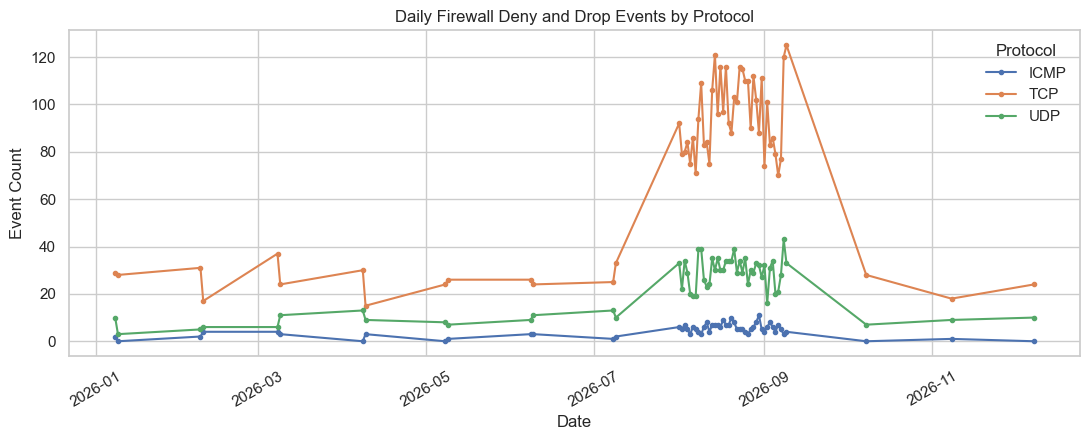

In [12]:
fw_deny = df_fw_clean[df_fw_clean['action'].isin(['deny', 'drop'])].dropna(subset=['timestamp']).copy()
fw_deny['date'] = fw_deny['timestamp'].dt.date
deny_trend = fw_deny.groupby(['date', 'protocol']).size().unstack(fill_value=0)

plt.figure(figsize=(11, 4.5))
for col in deny_trend.columns:
    plt.plot(deny_trend.index, deny_trend[col], marker='.', label=col.upper())
plt.title('Daily Firewall Deny and Drop Events by Protocol')
plt.xlabel('Date')
plt.ylabel('Event Count')
plt.xticks(rotation=30)
plt.legend(title='Protocol')
plt.tight_layout()
plt.show()


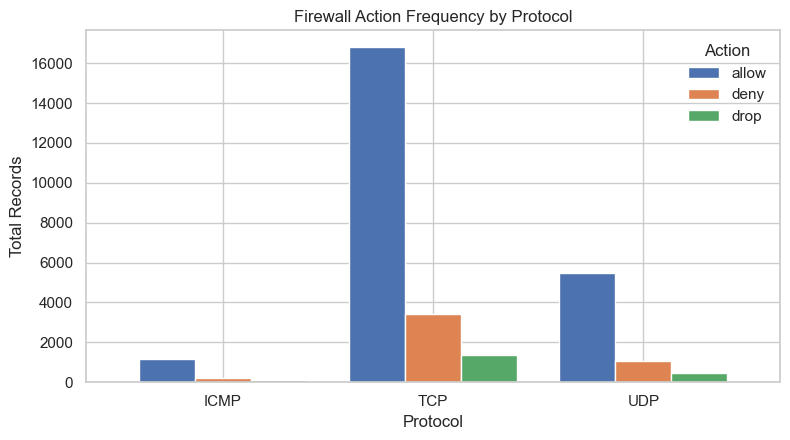

In [13]:
proto_action = df_fw_clean[df_fw_clean['protocol'].isin(['tcp', 'udp', 'icmp'])].groupby(['protocol', 'action']).size().unstack(fill_value=0)
proto_plot_df = proto_action[['allow', 'deny', 'drop']] if 'drop' in proto_action.columns else proto_action[['allow', 'deny']]

proto_plot_df.plot(kind='bar', figsize=(8, 4.5), width=0.8)
plt.title('Firewall Action Frequency by Protocol')
plt.xlabel('Protocol')
plt.ylabel('Total Records')
plt.xticks(ticks=range(len(proto_plot_df.index)), labels=[i.upper() for i in proto_plot_df.index], rotation=0)
plt.legend(title='Action')
plt.tight_layout()
plt.show()


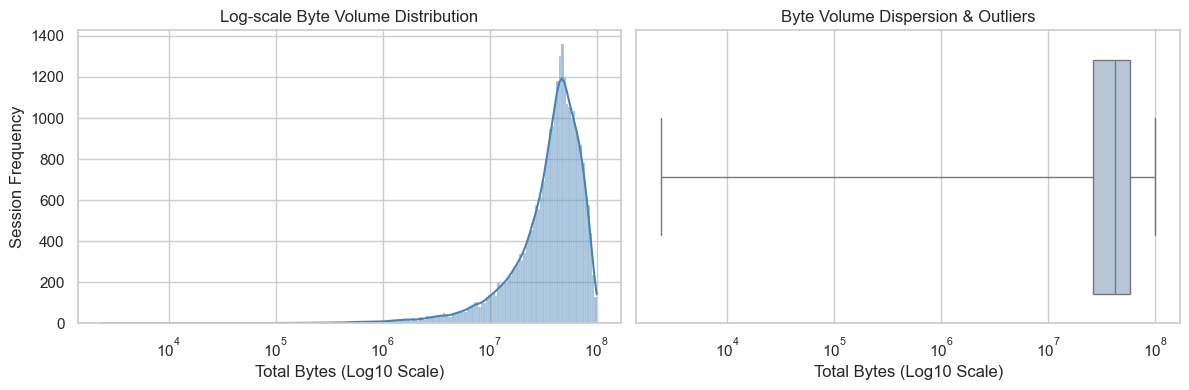

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
valid_bytes = df_fw_clean.loc[df_fw_clean['bytes_total'] > 0, 'bytes_total']

sns.histplot(valid_bytes, log_scale=True, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Log-scale Byte Volume Distribution')
axes[0].set_xlabel('Total Bytes (Log10 Scale)')
axes[0].set_ylabel('Session Frequency')

sns.boxplot(x=valid_bytes, ax=axes[1], color='lightsteelblue')
axes[1].set_xscale('log')
axes[1].set_title('Byte Volume Dispersion & Outliers')
axes[1].set_xlabel('Total Bytes (Log10 Scale)')

plt.tight_layout()
plt.show()


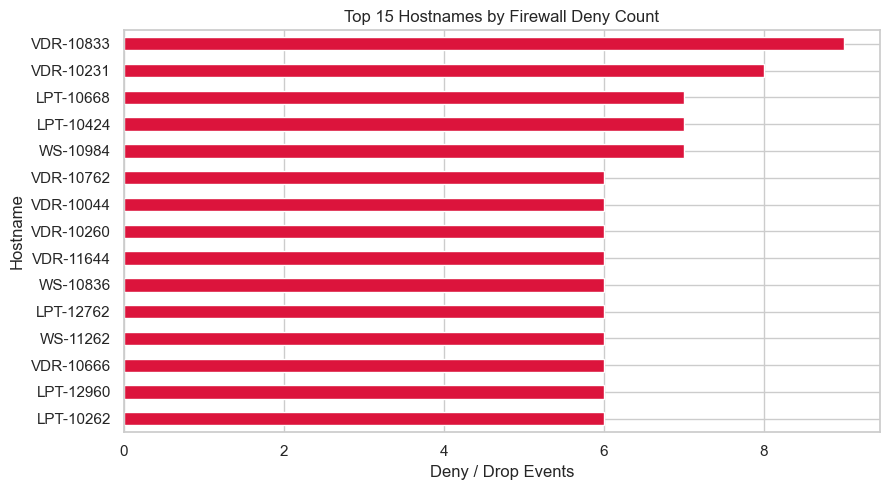

In [15]:
top_deny_hosts = fw_deny['hostname_clean'].dropna().value_counts().head(15)

plt.figure(figsize=(9, 5))
top_deny_hosts.sort_values().plot(kind='barh', color='crimson')
plt.title('Top 15 Hostnames by Firewall Deny Count')
plt.xlabel('Deny / Drop Events')
plt.ylabel('Hostname')
plt.tight_layout()
plt.show()


# EDA — IAM

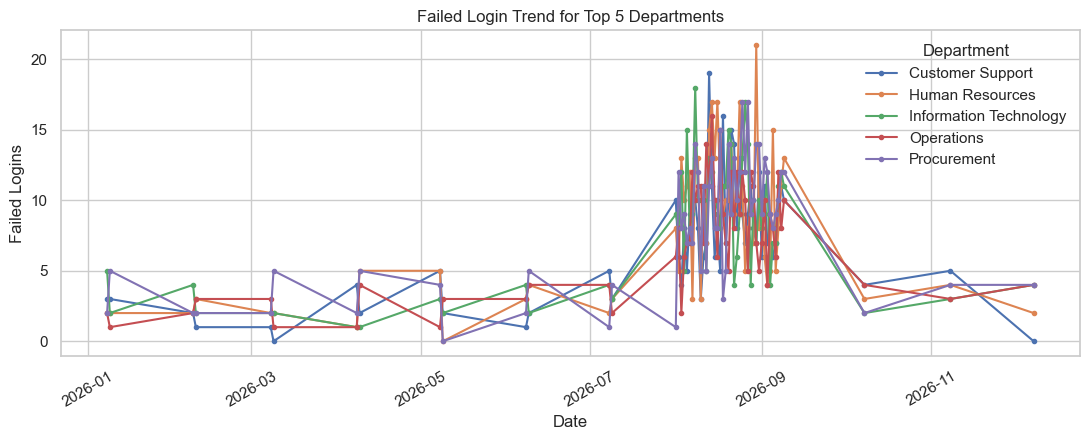

In [16]:
iam_failed = df_iam_clean[df_iam_clean['event_category'] == 'login_failed'].dropna(subset=['timestamp', 'department']).copy()
iam_failed['date'] = iam_failed['timestamp'].dt.date
top_depts = iam_failed['department'].value_counts().head(5).index
dept_trend = iam_failed[iam_failed['department'].isin(top_depts)].groupby(['date', 'department']).size().unstack(fill_value=0)

plt.figure(figsize=(11, 4.5))
for d in dept_trend.columns:
    plt.plot(dept_trend.index, dept_trend[d], marker='.', label=d)
plt.title('Failed Login Trend for Top 5 Departments')
plt.xlabel('Date')
plt.ylabel('Failed Logins')
plt.xticks(rotation=30)
plt.legend(title='Department')
plt.tight_layout()
plt.show()


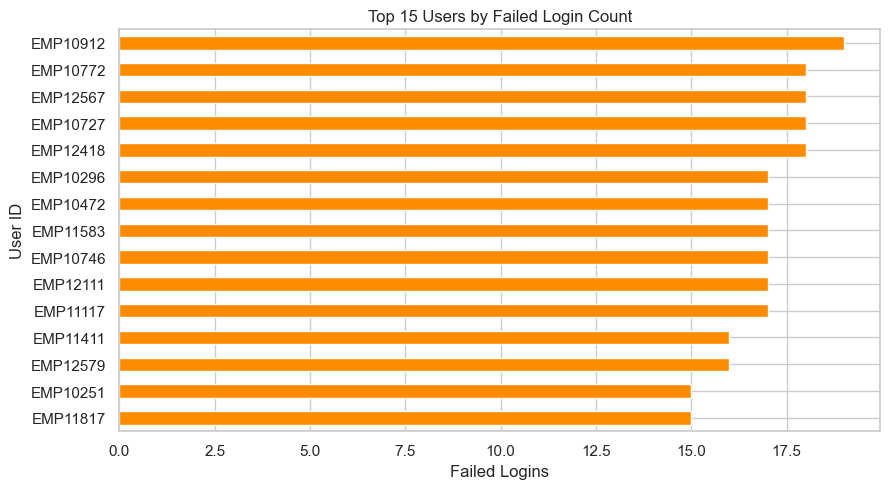

In [17]:
top_failed_users = iam_failed['user_id'].dropna().value_counts().head(15)

plt.figure(figsize=(9, 5))
top_failed_users.sort_values().plot(kind='barh', color='darkorange')
plt.title('Top 15 Users by Failed Login Count')
plt.xlabel('Failed Logins')
plt.ylabel('User ID')
plt.tight_layout()
plt.show()


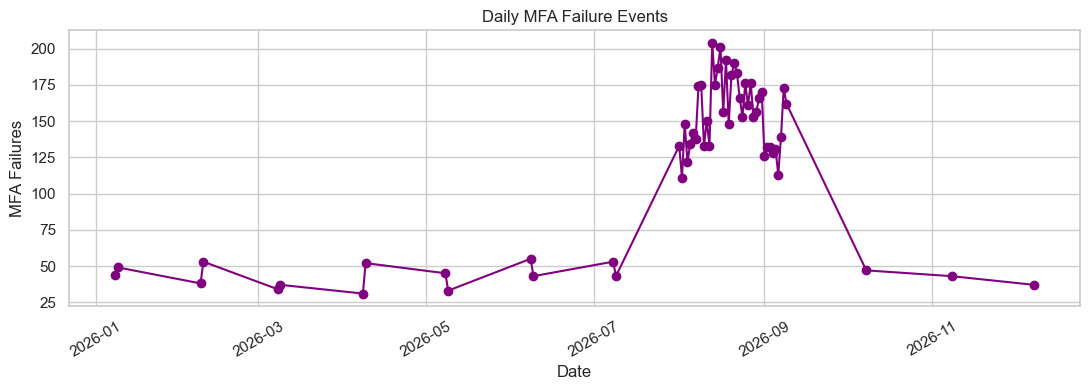

In [18]:
mfa_fails = df_iam_clean[(df_iam_clean['event_type'] == 'MFA_FAILED') | (df_iam_clean['mfa_passed'] == False)].dropna(subset=['timestamp']).copy()
mfa_fails['date'] = mfa_fails['timestamp'].dt.date
daily_mfa = mfa_fails.groupby('date').size()

plt.figure(figsize=(11, 4))
plt.plot(daily_mfa.index, daily_mfa.values, marker='o', color='purple')
plt.title('Daily MFA Failure Events')
plt.xlabel('Date')
plt.ylabel('MFA Failures')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


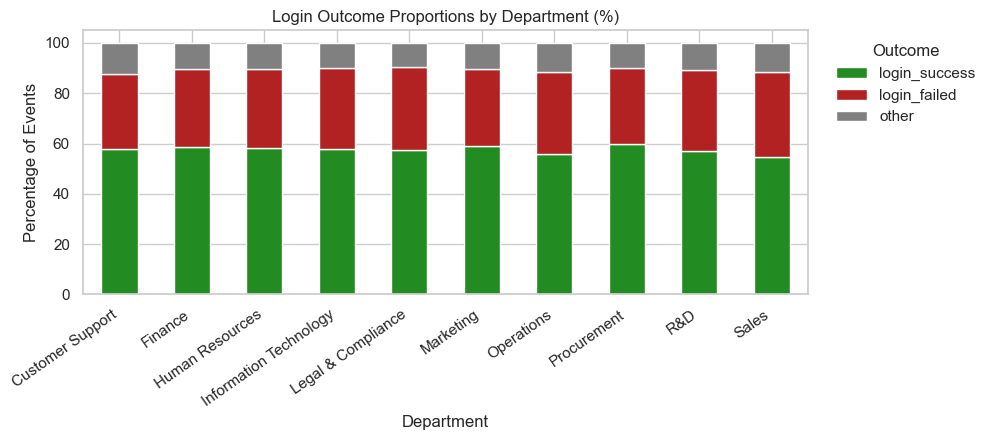

In [19]:
dept_outcomes = df_iam_clean.dropna(subset=['department']).groupby(['department', 'event_category']).size().unstack(fill_value=0)
dept_outcome_pct = dept_outcomes.div(dept_outcomes.sum(axis=1), axis=0) * 100

dept_outcome_pct[['login_success', 'login_failed', 'other']].plot(
    kind='bar', stacked=True, figsize=(10, 4.5), color=['forestgreen', 'firebrick', 'gray']
)
plt.title('Login Outcome Proportions by Department (%)')
plt.xlabel('Department')
plt.ylabel('Percentage of Events')
plt.xticks(rotation=35, ha='right')
plt.legend(title='Outcome', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


# EDA — endpoint alerts

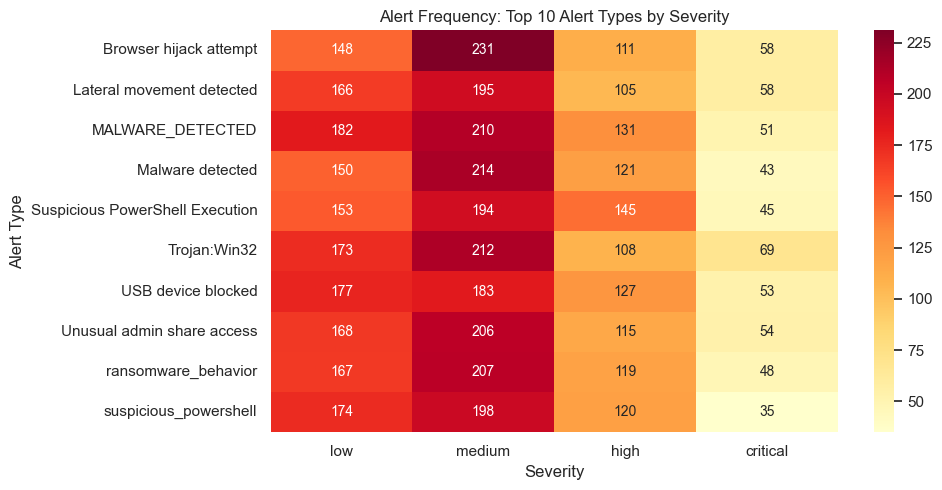

In [20]:
top_alert_types = df_ep_clean['alert_name'].value_counts().head(10).index
sev_type = df_ep_clean[df_ep_clean['alert_name'].isin(top_alert_types)].groupby(['alert_name', 'severity'], observed=False).size().unstack(fill_value=0)

plt.figure(figsize=(10, 5))
sns.heatmap(sev_type[['low', 'medium', 'high', 'critical']], annot=True, fmt='d', cmap='YlOrRd')
plt.title('Alert Frequency: Top 10 Alert Types by Severity')
plt.xlabel('Severity')
plt.ylabel('Alert Type')
plt.tight_layout()
plt.show()


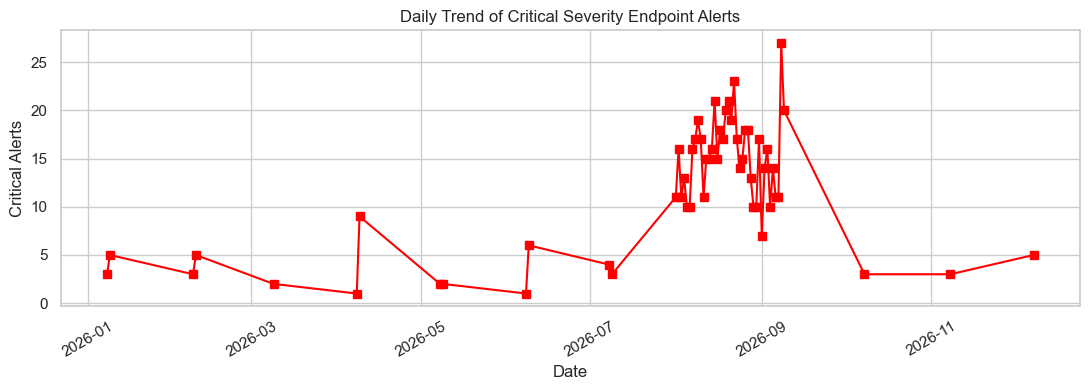

In [21]:
crit_alerts = df_ep_clean[df_ep_clean['severity'] == 'critical'].dropna(subset=['detected_timestamp']).copy()
crit_alerts['date'] = crit_alerts['detected_timestamp'].dt.date
daily_crit = crit_alerts.groupby('date').size()

plt.figure(figsize=(11, 4))
plt.plot(daily_crit.index, daily_crit.values, marker='s', color='red', linewidth=1.5)
plt.title('Daily Trend of Critical Severity Endpoint Alerts')
plt.xlabel('Date')
plt.ylabel('Critical Alerts')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [22]:
impossible_alerts = df_ep_clean[df_ep_clean['is_impossible_resolution']][
    ['user_id', 'hostname', 'alert_name', 'detected_timestamp', 'resolved_timestamp']
].rename(columns={
    'alert_name': 'alert',
    'detected_timestamp': 'detection_timestamp',
    'resolved_timestamp': 'resolution_timestamp'
})
print(f'Total impossible resolution records: {len(impossible_alerts)}')
print(impossible_alerts.head(10).to_string(index=False))


Total impossible resolution records: 663
 user_id  hostname                           alert detection_timestamp resolution_timestamp
EMP11158 LPT-11158            Phishing URL blocked 2026-08-05 00:31:08  2026-06-08 13:31:00
EMP11833 LPT-11833             Keylogger suspected 2026-08-29 08:30:00  2026-08-29 00:00:00
EMP10796 VDR-10796             Keylogger suspected 2026-12-08 04:24:00  2026-08-16 14:24:00
EMP12300 LPT-12300                Unauthorized USB 2026-08-30 12:51:12  2026-03-09 12:51:00
EMP10917 VDR-10917                Unauthorized USB 2026-08-29 10:56:29  2026-01-09 16:56:00
EMP10852 LPT-10852       Lateral movement detected 2026-08-10 04:27:02  2026-08-08 00:00:00
EMP12844 VDR-12844 Suspicious PowerShell Execution 2026-08-30 09:08:55  2026-03-09 03:08:00
EMP11884 LPT-11884      Credential dumping attempt 2026-09-08 01:32:28  2026-08-09 03:32:00
EMP12544  WS-12544                MALWARE_DETECTED 2026-08-02 21:19:23  2026-08-02 06:19:23
EMP10740 VDR-10740             Ransomwa

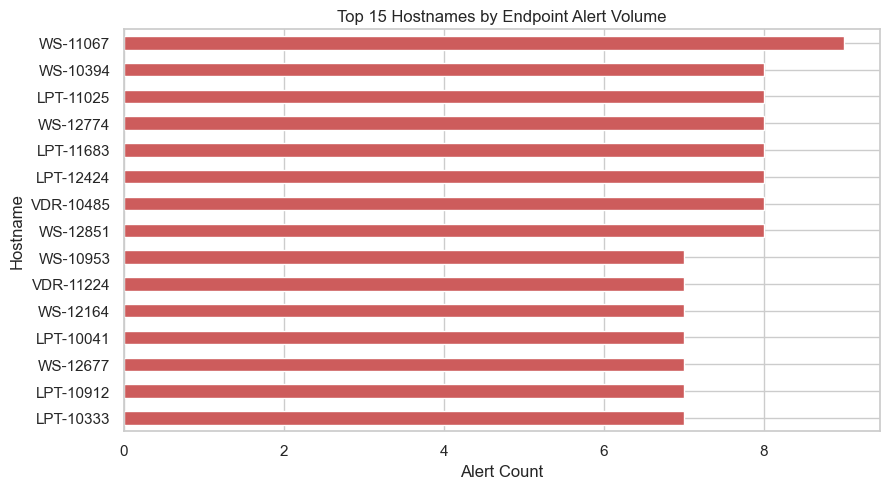

In [23]:
top_alert_hosts = df_ep_clean['hostname_clean'].dropna().value_counts().head(15)

plt.figure(figsize=(9, 5))
top_alert_hosts.sort_values().plot(kind='barh', color='indianred')
plt.title('Top 15 Hostnames by Endpoint Alert Volume')
plt.xlabel('Alert Count')
plt.ylabel('Hostname')
plt.tight_layout()
plt.show()


# Cross-dataset

In [24]:
user_fails = df_iam_clean[df_iam_clean['event_category'] == 'login_failed'].groupby('user_id').size().rename('failed_logins')
user_alerts = df_ep_clean.groupby('user_id').size().rename('endpoint_alerts')

suspicious_users = pd.concat([user_fails, user_alerts], axis=1).dropna()
suspicious_users['combined_frequency'] = (suspicious_users['failed_logins'] + suspicious_users['endpoint_alerts']).astype(int)
suspicious_users['failed_logins'] = suspicious_users['failed_logins'].astype(int)
suspicious_users['endpoint_alerts'] = suspicious_users['endpoint_alerts'].astype(int)
suspicious_users = suspicious_users.sort_values(by='combined_frequency', ascending=False)

print('Top 15 suspicious users by combined anomaly frequency:')
print(suspicious_users.head(15).to_string())


Top 15 suspicious users by combined anomaly frequency:
          failed_logins  endpoint_alerts  combined_frequency
user_id                                                     
EMP10296             34                4                  38
EMP10912             25                7                  32
EMP10746             26                4                  30
EMP10772             27                2                  29
EMP12579             24                5                  29
EMP11411             24                5                  29
EMP11117             25                4                  29
EMP11583             26                3                  29
EMP12418             27                2                  29
EMP10472             25                3                  28
EMP12425             26                2                  28
EMP10251             23                5                  28
EMP12567             25                3                  28
EMP12111             27       

In [25]:
iam_user_daily = df_iam_clean[df_iam_clean['event_category'] == 'login_failed'].dropna(subset=['timestamp', 'user_id']).copy()
iam_user_daily['date'] = iam_user_daily['timestamp'].dt.date
iam_counts = iam_user_daily.groupby(['user_id', 'date']).size().rename('failed_login_count')

ep_user_daily = df_ep_clean.dropna(subset=['detected_timestamp', 'user_id']).copy()
ep_user_daily['date'] = ep_user_daily['detected_timestamp'].dt.date
ep_counts = ep_user_daily.groupby(['user_id', 'date']).size().rename('endpoint_alert_count')

cooccur = pd.concat([iam_counts, ep_counts], axis=1, join='inner').reset_index()
cooccur['total_events'] = cooccur['failed_login_count'] + cooccur['endpoint_alert_count']
cooccur = cooccur.sort_values(by='total_events', ascending=False)

print('Top 15 same-user same-day event co-occurrences:')
print(cooccur.head(15).to_string(index=False))


Top 15 same-user same-day event co-occurrences:
 user_id       date  failed_login_count  endpoint_alert_count  total_events
EMP10194 2026-08-14                   3                     1             4
EMP10847 2026-08-12                   1                     2             3
EMP11090 2026-08-11                   2                     1             3
EMP11152 2026-08-29                   1                     2             3
EMP10977 2026-08-30                   1                     2             3
EMP12696 2026-08-12                   2                     1             3
EMP11353 2026-08-26                   1                     2             3
EMP10454 2026-06-09                   2                     1             3
EMP10296 2026-08-08                   2                     1             3
EMP10296 2026-09-03                   2                     1             3
EMP10601 2026-08-15                   1                     2             3
EMP10912 2026-08-15                   2 

# Findings

- 66.8% of distinct user_id values across telemetry logs appeared in non-canonical formats (bare numeric, lowercase, hyphenated, underscore, or spaced) prior to normalization.
- Deduplication on natural keys eliminated 90 duplicate identity records, 500 IAM events, 600 firewall logs, and 240 endpoint alerts.
- Exactly 663 endpoint alert records (8.29% of unique alerts) show resolution timestamps occurring before detection timestamps.
- Malformed IP addresses were detected in 13,730 firewall source IPs, 13,027 firewall destination IPs, and 10,375 IAM source IPs.
- 2,674 IAM audit records contained out-of-range risk scores, and 1,384 records contained text ratings rather than numeric values.
- IAM audit trail matched 100% of canonical user_id keys in identity master, while endpoint alerts achieved an 84.3% match rate on normalized composite keys.
- User EMP10296 recorded the highest combined threat signal across sources, with 34 failed logins and 4 endpoint alerts.
- Maximum single-day correlated anomaly concentration occurred on 2026-08-14 for user EMP10194, with 4 failed logins and 1 endpoint alert.
